In [1]:
!pip install thop



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.

In [1]:
!pip -q install fvcore thop

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[Unlabeled] 300 images from /kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024/archive/val/val


/tmp/ipykernel_38/3296863211.py:132: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  markerline, stemlines, baseline = ax0.stem(


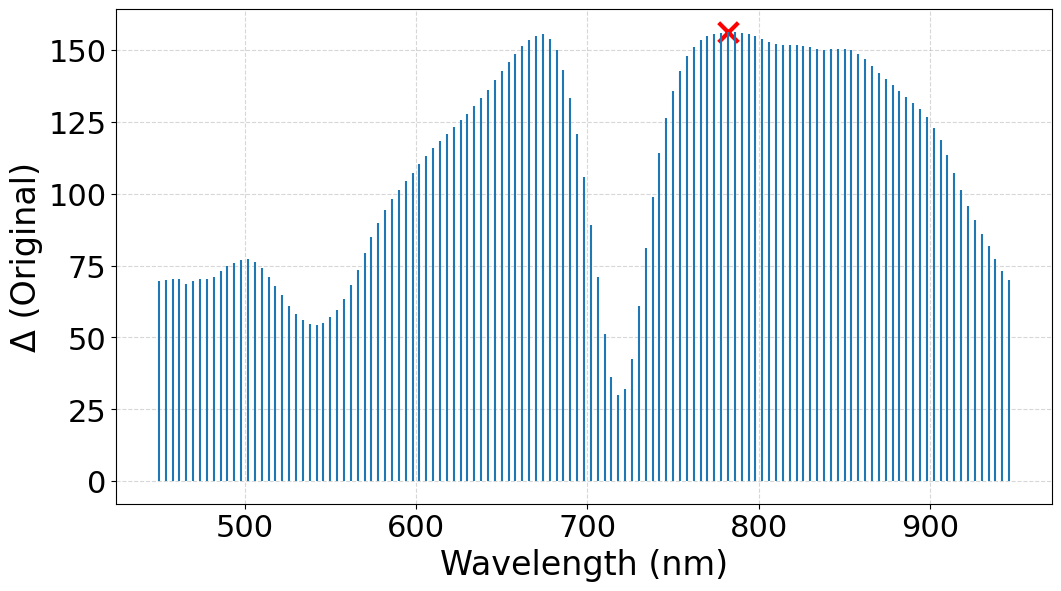

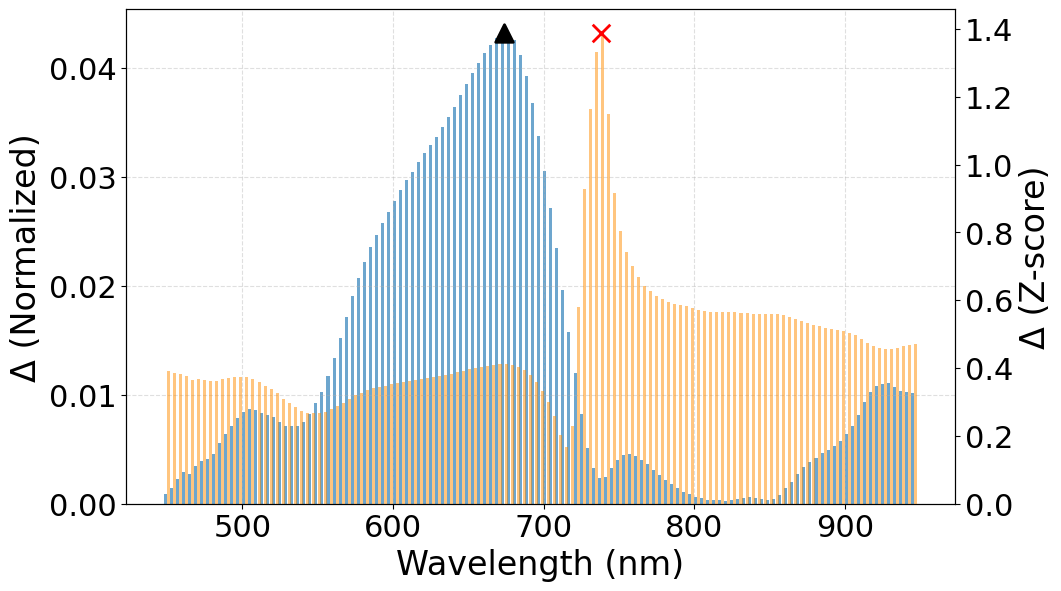

In [1]:
# ────────────────────────────── 1. 라이브러리 및 설정 ──────────────────────────────
import os, copy, math, random, warnings, time, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage import io
from skimage.transform import resize as sk_resize
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, classification_report, confusion_matrix,  recall_score, cohen_kappa_score
import torch
import torch.nn as nn
import torch.nn.functional as F           
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
import re
from torch.utils.data import Sampler
from math import sqrt
from sklearn.manifold import TSNE
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from matplotlib import cm

from IPython.display import display
import math


warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# ────────────────────────────── 2. 경로 및 클래스 설정 ──────────────────────────────
BASE_DIR_HSI = "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024"
TRAIN_DIR_HSI = os.path.join(BASE_DIR_HSI, "archive/train")

CLASSES_HSI = ["Health", "Other", "Rust"]
WAVELENGTHS      = np.arange(450, 950, 4)

# ────────────────────────────── 2-추가. 언라벨드 데이터 경로 ──────────────────────────────
UNLABELED_DIR_HSI = "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2024/archive/val/val"
UNLABELED_EXTS = (".tif", ".tiff")

# ────────────────────────────── 3-추가. 언라벨드 DF 헬퍼 ──────────────────────────────
def create_unlabeled_dataframe(base_dir, file_exts=UNLABELED_EXTS):
    records = []
    if os.path.isdir(base_dir):
        for f in os.listdir(base_dir):
            if f.lower().endswith(file_exts):
                records.append({"path": os.path.join(base_dir, f)})
    return pd.DataFrame(records)

# ────────────────────────────── 4-추가. 언라벨드 DF 로딩 ──────────────────────────────
unlabeled_df = create_unlabeled_dataframe(UNLABELED_DIR_HSI)
print(f"[Unlabeled] {len(unlabeled_df)} images from {UNLABELED_DIR_HSI}")


# ────────────────────────────── 3. 헬퍼 함수 정의 ──────────────────────────────
def load_hsi(path, wavelengths=WAVELENGTHS):
    arr = io.imread(path).astype(np.float32)
    assert arr.ndim == 3, f"Unexpected HSI shape: {arr.shape}"
    band_axis = int(np.argmin([abs(s - len(wavelengths)) for s in arr.shape]))
    return np.moveaxis(arr, band_axis, -1)

def create_dataframe(base_dir, classes, file_exts, class_map=None):
    records = []
    for cls in (class_map.keys() if class_map else classes):
        d = os.path.join(base_dir, cls)
        if os.path.isdir(d):
            for f in os.listdir(d):
                if f.lower().endswith(file_exts):
                    label = class_map.get(cls, cls) if class_map else cls
                    records.append({"label": label, "path": os.path.join(d, f)})
    return pd.DataFrame(records)

def compute_hsi_mean_spectra_full(df, classes):
    spectra_o = {c: [] for c in classes}
    min_len = float("inf")
    for cls in classes:
        for p in df[df.label == cls].path:
            v = load_hsi(p).mean(axis=(0, 1))
            spectra_o[cls].append(v)
            min_len = min(min_len, len(v))
    wl_axis = WAVELENGTHS[:min_len]
    avg_o = {c: np.vstack([v[:min_len] for v in spectra_o[c]]).mean(axis=0) if spectra_o[c] else np.zeros(min_len) for c in classes}
    return avg_o, wl_axis

def safe_norm(v):
    v = np.nan_to_num(v)
    mn, mx = v.min(), v.max()
    return np.zeros_like(v) if mx == mn else (v - mn) / (mx - mn)

def moving_avg(x, k=5):
    k = max(3, k | 1)
    pad = k // 2
    xp = np.pad(x, (pad, pad), mode='edge')
    return np.convolve(xp, np.ones(k) / k, mode='valid')

# ────────────────────────────── 4. 데이터 로딩 및 스펙트럼 계산 ──────────────────────────────
hsi_df = create_dataframe(TRAIN_DIR_HSI, CLASSES_HSI, (".tif",))

avg_hsi_o, wl_axis = compute_hsi_mean_spectra_full(hsi_df, CLASSES_HSI)
avg_hsi_n = {c: safe_norm(avg_hsi_o[c]) for c in CLASSES_HSI}
mu_all = np.stack(list(avg_hsi_o.values())).mean(axis=0)
sd_all = np.stack(list(avg_hsi_o.values())).std(axis=0) + 1e-8
avg_hsi_z = {c: (avg_hsi_o[c] - mu_all) / sd_all for c in avg_hsi_o}

# ────────────────────────────── 5. 스펙트럼 차이 계산 및 피크 탐지 ──────────────────────────────
delta_o_abs = np.abs(avg_hsi_o["Health"] - avg_hsi_o["Rust"])
delta_n_abs = np.abs(avg_hsi_n["Health"] - avg_hsi_n["Rust"])
delta_z_abs = np.abs(avg_hsi_z["Health"] - avg_hsi_z["Rust"])

d_o, d_n, d_z = moving_avg(delta_o_abs), moving_avg(delta_n_abs), moving_avg(delta_z_abs)
peak_idx_o, peak_idx_n, peak_idx_z = np.argmax(d_o), np.argmax(d_n), np.argmax(d_z)

# ────────────────────────────── 6. 시각화 (Discrete + 2 Figures) ──────────────────────────────

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
})

wl_axis_ma = wl_axis[:len(d_o)]

# =========================================================
# Figure 1: Original Scale (Discrete Stem Plot)
#  - 가로 줄임 + constrained_layout 사용
# =========================================================
fig, ax0 = plt.subplots(1, 1, figsize=(10.5, 5.8), constrained_layout=True)

markerline, stemlines, baseline = ax0.stem(
    wl_axis_ma, d_o,
    basefmt=" ", markerfmt=" ",
    use_line_collection=True,
)
markerline.set_visible(False)

ax0.scatter(
    wl_axis_ma[peak_idx_o], d_o[peak_idx_o],
    marker="x", c="red", s=200, linewidth=3
)

ax0.set_xlabel("Wavelength (nm)")
ax0.set_ylabel("Δ (Original)")
ax0.grid(ls="--", alpha=0.5)

plt.show()


# =========================================================
# Figure 2: Normalized vs Z-Score (Discrete Bars + Dual Y-Axis)
#  - 가로 줄임 + constrained_layout 사용
# =========================================================
fig, ax_left = plt.subplots(1, 1, figsize=(10.5, 5.8), constrained_layout=True)
ax_right = ax_left.twinx()

bar_w  = 2.0
offset = bar_w * 0.55

bars_n = ax_left.bar(
    wl_axis_ma - offset, d_n[:len(wl_axis_ma)],
    width=bar_w, align="center",
    alpha=0.65, edgecolor="none",
)

bars_z = ax_right.bar(
    wl_axis_ma + offset, d_z[:len(wl_axis_ma)],
    width=bar_w, align="center",
    alpha=0.50, edgecolor="none",
    color="darkorange",
)

ax_left.scatter(
    wl_axis_ma[peak_idx_n], d_n[peak_idx_n],
    marker="^", c="black", s=160, linewidth=2,
)

ax_right.scatter(
    wl_axis_ma[peak_idx_z], d_z[peak_idx_z],
    marker="x", c="red", s=160, linewidth=2,
)

ax_left.set_xlabel("Wavelength (nm)")
ax_left.set_ylabel("Δ (Normalized)")
ax_right.set_ylabel("Δ (Z-score)")

ax_left.grid(ls="--", alpha=0.4)

plt.show()




In [2]:
# ────────────────────────────── 셀 2: 설정 클래스 (CFG) ──────────────────────────────
class CFG:
    # 기본
    seed = 42
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 밴드 선택 설정
    prior_wavelengths = (531, 554, 570, 667, 670, 700)
    adjcorr_threshold = 0.95
    snr_quantile = 0.25


    # 모델/학습
    n_folds = 5
    hsi_img_size   = 128          # [동일] 1D/2D 전처리에서 만들 크기(H,W)
    rgb_input_size = 224          # [동일] ResNet-18 입력 크기
    hsi_epochs     = 50
    hsi_batch_size = 16
    hsi_wd         = 3e-4

    # 손실/라벨 스무딩
    hsi_ls = 0.02

    # C1: Discriminative LR (예전과 동일)
    lr_head = 2e-4 
    lr_l1l2 = 5e-6 
    lr_l3   = 1e-5 
    lr_l4   = 2e-5 

    # 스케줄러/얼리스탑
    reduce_patience = 5
    reduce_factor   = 0.5
    es_patience     = 8

    # 로깅/타이밍
    log_confusion_matrix = True
    measure_timing = True
    output_dir = "./output"
    model_dir  = os.path.join(output_dir, "models")
    os.makedirs(model_dir, exist_ok=True)

    # 증강 스위치 (모두 OFF 시작)
    use_2d_rrc         = False
    use_2d_jitter      = False
    use_1d_band_shift  = False
    use_1d_gauss_noise = False
    noise_sigma        = 0.006

    # [유지] 데이터 불균형 대책(후순위)
    use_balanced_batches = True
    use_weighted_sampler = False
    use_focal_loss       = False
    focal_alpha          = [1.5, 1.0, 1.0]  # [Health, Other, Rust]
 
    # NDVI에 사용할 밴드(존재하지 않을 때는 근접 nm 자동 선택)
    ndvi_red_nm_list  = [658, 662, 666, 670, 674]   # mean(RED)
    ndvi_nir_primary  = [774, 778, 782, 786, 790] # 782



def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

set_seed(CFG.seed)



--- [밴드 선택] 2D 브랜치용 (3개 피크) ---
- 파장(nm): 674
- 파장(nm): 738
- 파장(nm): 782

--- [밴드 선택] 1D 브랜치용 (전체, 7개) ---
- 이름: OriginalBand_530nm, 유형: 원본 밴드, 파장(nm): [530]
- 이름: OriginalBand_554nm, 유형: 원본 밴드, 파장(nm): [554]
- 이름: OriginalBand_570nm, 유형: 원본 밴드, 파장(nm): [570]
- 이름: MeanBand_666nm, 유형: 평균화된 그룹, 파장(nm): [658, 662, 666, 670, 674]
- 이름: OriginalBand_698nm, 유형: 원본 밴드, 파장(nm): [698]
- 이름: OriginalBand_738nm, 유형: 원본 밴드, 파장(nm): [738]
- 이름: OriginalBand_782nm, 유형: 원본 밴드, 파장(nm): [782]


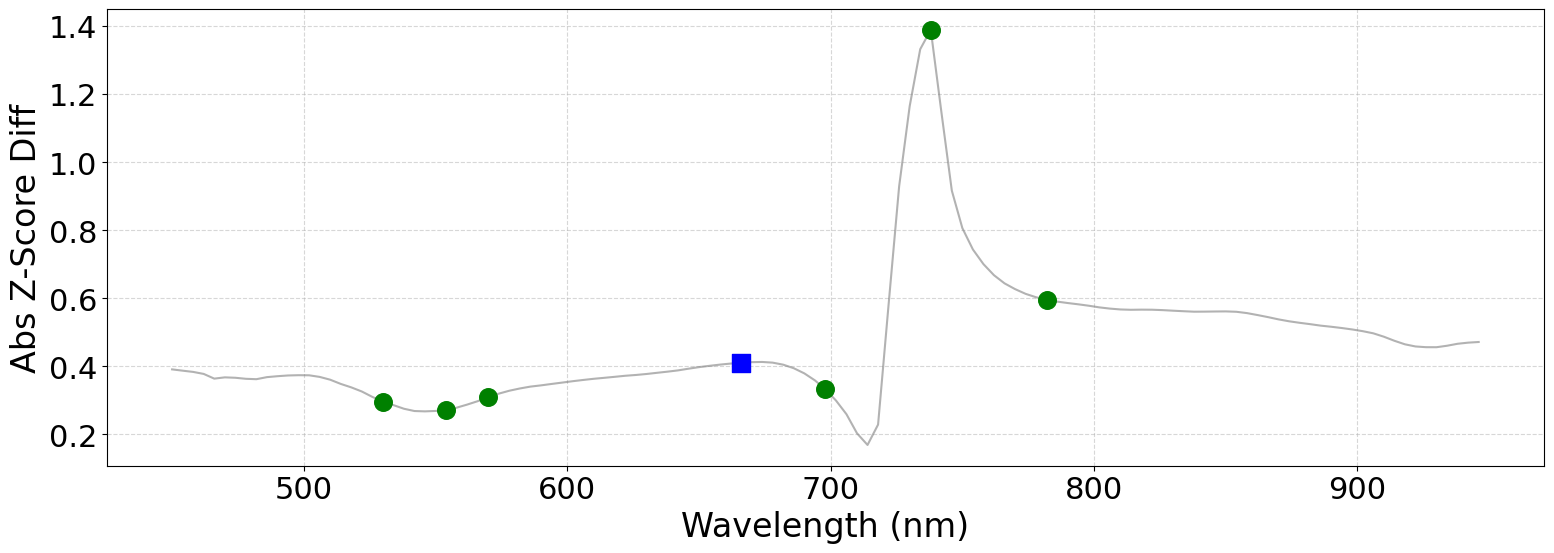

In [3]:
# ────────────────────────────── 셀 3: 밴드 선택/유틸 (기존 유지) ──────────────────────────────
# ── 1. 유틸리티 함수 ──

# def stratified_split(df, label_col='label', seed=42, train_ratio=0.7, val_ratio=0.15):
#     tr, tmp = train_test_split(df, test_size=1-train_ratio, stratify=df[label_col], random_state=seed)
#     val_rel_ratio = val_ratio / (1 - train_ratio)
#     va, te = train_test_split(tmp, test_size=1-val_rel_ratio, stratify=tmp[label_col], random_state=seed)
#     return tr.reset_index(drop=True), va.reset_index(drop=True), te.reset_index(drop=True)
    
def nearest_idx(wavelength_axis, target_nm):
    return int(np.argmin(np.abs(wavelength_axis - target_nm)))
    
def estimate_snr_and_adjcorr(df, wl_axis, max_imgs=500, seed=42):
    rng = np.random.RandomState(seed)
    paths = rng.choice(df['path'].tolist(), size=min(len(df), max_imgs), replace=False)
    M = np.vstack([load_hsi(p).mean(axis=(0, 1))[:len(wl_axis)] for p in paths])
    mu = M.mean(0)
    sd = M.std(0) + 1e-8
    snr = mu / sd
    B = M.shape[1]
    adj = np.zeros(B)
    for i in range(B - 1):
        ci = np.corrcoef(M[:, i], M[:, i + 1])[0, 1]
        adj[i] = 0.0 if np.isnan(ci) else ci
    if B > 1:
        adj[B - 1] = adj[B - 2]
    return snr, adj, M

def find_max_slope_bands(curve, n_bands):
    if len(curve) < 2: return []
    gradient = np.abs(np.gradient(curve))
    top_indices = np.argsort(gradient)[-n_bands:]
    return sorted(top_indices)

def select_bands_A_from_curves(avg_hsi_o, avg_hsi_n, avg_hsi_z, wl_axis, cfg):
    def moving_avg(x, k=5):
        k = max(3, k | 1); pad = k // 2
        xp = np.pad(x, (pad, pad), mode='edge')
        return np.convolve(xp, np.ones(k)/k, mode='valid')

    d_o = moving_avg(np.abs(avg_hsi_o["Health"] - avg_hsi_o["Rust"]))
    d_n = moving_avg(np.abs(avg_hsi_n["Health"] - avg_hsi_n["Rust"]))
    d_z = moving_avg(np.abs(avg_hsi_z["Health"] - avg_hsi_z["Rust"]))

    peak_indices_3 = sorted(list(set([np.argmax(d_o), np.argmax(d_n), np.argmax(d_z)])))
    bands_for_2d = [('PeakBand', [idx]) for idx in peak_indices_3]

    candidates = set(peak_indices_3) | set([nearest_idx(wl_axis, nm) for nm in CFG.prior_wavelengths])
    
    hsi_bin = hsi_df[hsi_df.label.isin(["Health", "Rust"])]
    snr, adj, M = estimate_snr_and_adjcorr(hsi_bin, wl_axis, seed=CFG.seed)
    snr_threshold = np.quantile(snr, CFG.snr_quantile)

    bands_for_1d, processed = [], set()
    for idx in sorted(list(candidates)):
        if idx in processed: continue
        is_noisy = snr[idx] < snr_threshold
        group = {idx}
        # 좌우 확장(±2, 고상관)
        left_idx = idx - 1
        while left_idx >= 0 and adj[left_idx] > CFG.adjcorr_threshold and (idx - left_idx) <= 2:
            group.add(left_idx); left_idx -= 1
        right_idx = idx
        while right_idx < len(adj)-1 and adj[right_idx] > CFG.adjcorr_threshold and (right_idx + 1 - idx) <= 2:
            group.add(right_idx + 1); right_idx += 1
        group = sorted(list(group))

        if is_noisy and len(group) > 1:
            mean_band_pixels = M[:, group].mean(axis=1)
            snr_after = mean_band_pixels.mean() / (mean_band_pixels.std() + 1e-8)
            if snr_after > snr[idx]:
                band_name = f"MeanBand_{int(wl_axis[int(np.mean(group))])}nm"
                bands_for_1d.append((band_name, group)); processed.update(group)
            else:
                bands_for_1d.append((f"OriginalBand_{int(wl_axis[idx])}nm", [idx])); processed.add(idx)
        else:
            bands_for_1d.append((f"OriginalBand_{int(wl_axis[idx])}nm", [idx])); processed.add(idx)

    return bands_for_2d, bands_for_1d, d_z

# === 실행 ===
bands_2d, bands_1d, final_d_z = select_bands_A_from_curves(avg_hsi_o, avg_hsi_n, avg_hsi_z, wl_axis, CFG)


print("--- [밴드 선택] 2D 브랜치용 (3개 피크) ---")
for name, indices in bands_2d:
    print(f"- 파장(nm): {int(wl_axis[indices[0]])}")

print(f"\n--- [밴드 선택] 1D 브랜치용 (전체, {len(bands_1d)}개) ---")
for name, indices in bands_1d:
    band_type = "평균화된 그룹" if "Mean" in name else "원본 밴드"
    wavelengths = [int(wl_axis[i]) for i in indices]
    print(f"- 이름: {name}, 유형: {band_type}, 파장(nm): {wavelengths}")

# (선택) 시각화
fig, ax = plt.subplots(figsize=(16, 6))

# 전체 기본 폰트 조금 키우기
plt.rcParams.update({
    "font.size": 22,        # 기본
    "axes.labelsize": 24,   # x/y 라벨
    "xtick.labelsize": 22,  # x tick 숫자
    "ytick.labelsize": 22,  # y tick 숫자
})

# 곡선
ax.plot(
    wl_axis,
    final_d_z,
    color="gray",
    alpha=0.6
)

mean_bands = [item for item in bands_1d if "Mean" in item[0]]
orig_bands = [item for item in bands_1d if "Original" in item[0]]

# 평균 그룹 밴드
if mean_bands:
    mean_indices = [int(np.mean(item[1])) for item in mean_bands]
    ax.scatter(
        wl_axis[mean_indices],
        final_d_z[mean_indices],
        c="blue",
        marker="s",
        s=180,
        zorder=5
    )

# 원본 밴드
if orig_bands:
    orig_indices = [item[1][0] for item in orig_bands]
    ax.scatter(
        wl_axis[orig_indices],
        final_d_z[orig_indices],
        c="green",
        marker="o",
        s=160,
        zorder=5
    )

# 축 라벨 (제목, legend 없음)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Abs Z-Score Diff")
ax.grid(ls="--", alpha=0.5)

# 혹시 모를 tick 폰트 보정
ax.tick_params(axis="both", which="major", labelsize=22)

plt.tight_layout()
plt.show()


In [5]:
# ────────────────────────────── 셀 4: 데이터셋, 증강 및 데이터로더 ──────────────────────────────

# ── 1) HSI 전처리 ──
def process_hsi_cube(cube, band_defs):
    processed = []
    for _, indices in band_defs:
        if len(indices) > 1:
            processed.append(cube[:, :, indices].mean(axis=2, keepdims=True))
        else:
            processed.append(cube[:, :, indices])
    return np.concatenate(processed, axis=2)

def resize_hsi(cube, out_hw):
    out_shape = (out_hw[0], out_hw[1], cube.shape[2])
    return sk_resize(cube, out_shape, order=1, mode='reflect', anti_aliasing=True).astype(np.float32)

# ── 2) 공통 공간 증강(2D/1D): 플립/회전 ──
def hsi_augmentations(cube):
    if np.random.rand() < 0.5: cube = np.fliplr(cube).copy()
    if np.random.rand() < 0.5: cube = np.flipud(cube).copy()
    k = np.random.randint(0, 4)
    if k > 0: cube = np.rot90(cube, k, axes=(0, 1)).copy()
    return cube


# ── 5) Dataset ──
class HSIDataset(Dataset):
    """
      - 2D는 224×224로 리사이즈 후 ToTensor + ImageNet 정규화
      - 1D는 (선택밴드 추출 → [옵션]밴드시프트 → z-score → 공간증강 → out_hw=128로 리사이즈)
    """
    def __init__(self, df, bands_2d, bands_1d, mu_1d, std_1d, label_map,
                 train=True, out_hw=(128,128)):
        self.df = df.reset_index(drop=True)
        self.bands_2d = bands_2d
        self.bands_1d = bands_1d
        self.mu_1d = mu_1d
        self.std_1d = std_1d
        self.label_map = label_map
        self.train = train
        self.out_hw = out_hw

        # 2D: ImageNet 정규화 (예전과 동일)
        self.tf_2d = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, i):
        full = load_hsi(self.df.iloc[i].path)

        # --- 2D branch ---
        cube_2d = process_hsi_cube(full, self.bands_2d)
        if self.train:
            cube_2d = hsi_augmentations(cube_2d)
            if CFG.use_2d_rrc:
                cube_2d = rand_resized_crop_np(cube_2d, scale=(0.7,1.0),
                                               out_hw=(CFG.rgb_input_size, CFG.rgb_input_size))
            else:
                cube_2d = resize_hsi(cube_2d, (CFG.rgb_input_size, CFG.rgb_input_size))
            if CFG.use_2d_jitter:
                cube_2d = color_jitter_np(cube_2d, max_delta=0.10)
        else:
            cube_2d = resize_hsi(cube_2d, (CFG.rgb_input_size, CFG.rgb_input_size))
        x_2d = self.tf_2d(cube_2d.astype(np.float32))  # ToTensor + 정규화

        # --- 1D branch (예전 흐름 복원 + 새 밴드시프트 유지) ---
        if self.train and CFG.use_1d_band_shift:
            # [변경] 선택밴드 ‘밖’을 원본에서 가져오는 shift
            cube_1d = band_shift_from_full(full, self.bands_1d)
        else:
            cube_1d = process_hsi_cube(full, self.bands_1d)

        cube_1d = (cube_1d - self.mu_1d) / self.std_1d  # z-score 

        if self.train:
            cube_1d = hsi_augmentations(cube_1d)        # 공간 증강
            if CFG.use_1d_gauss_noise:
                cube_1d = add_gaussian_noise_np(cube_1d, sigma=CFG.noise_sigma)

        # 128×128로 리사이즈 후 텐서 변환
        cube_1d = resize_hsi(cube_1d, self.out_hw)      
        x_1d = torch.from_numpy(cube_1d.transpose(2,0,1)).float()

        y = torch.tensor(self.label_map[self.df.iloc[i].label], dtype=torch.long)
        return (x_2d, x_1d), y, i 
        
def hsi_hybrid_collate(batch):
    first = batch[0]
    if len(first) == 3:
        x2d_list, x1d_list, y_list, idx_list = [], [], [], []
        for ((a, b), t, i) in batch:
            x2d_list.append(a); x1d_list.append(b); y_list.append(t); idx_list.append(i)
        x2d = torch.stack(x2d_list, dim=0)
        x1d = torch.stack(x1d_list, dim=0)
        y   = torch.stack(y_list, dim=0) if torch.is_tensor(y_list[0]) else torch.as_tensor(y_list, dtype=torch.long)
        idxs= torch.as_tensor(idx_list, dtype=torch.long)
        return (x2d, x1d), y, idxs
    else:
        # 레거시: ((x2d,x1d), y)만 올 때
        xs, ys = zip(*batch)
        x_2ds, x_1ds = zip(*xs)
        x2d = torch.stack(x_2ds, 0); x1d = torch.stack(x_1ds, 0)
        y   = torch.stack(ys, 0) if torch.is_tensor(ys[0]) else torch.as_tensor(ys, dtype=torch.long)
        idx = torch.arange(y.size(0), dtype=torch.long)
        return (x2d, x1d), y, idx

# 폴드별 μ/σ 계산(누수 방지)
def compute_band_stats(df, band_defs, max_imgs=None, seed=42):
    rng = np.random.RandomState(seed)
    paths_all = df['path'].tolist()
    paths = paths_all if (max_imgs is None or max_imgs >= len(paths_all)) \
            else rng.choice(paths_all, size=max_imgs, replace=False)
    processed_cubes = [process_hsi_cube(load_hsi(p), band_defs) for p in paths]
    per_img_vec = [cube.mean(axis=(0, 1)) for cube in processed_cubes]
    all_bands_mean = np.mean(per_img_vec, axis=0)
    all_bands_std  = np.std(per_img_vec,  axis=0) + 1e-8
    return all_bands_mean, all_bands_std

# ---- TestDataset (id 반환) ----
class HSITestDataset(Dataset):
    def __init__(self, df, bands_2d, bands_1d, mu_1d, std_1d, out_hw=(128,128)):
        self.df = df.reset_index(drop=True)
        self.bands_2d = bands_2d
        self.bands_1d = bands_1d
        self.mu_1d = mu_1d
        self.std_1d = std_1d
        self.out_hw = out_hw

        self.tf_2d = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, i):
        full = load_hsi(self.df.iloc[i].path)

        # 2D
        cube_2d = process_hsi_cube(full, self.bands_2d)
        cube_2d = resize_hsi(cube_2d, (CFG.rgb_input_size, CFG.rgb_input_size))
        x_2d = self.tf_2d(cube_2d.astype(np.float32))

        # 1D (예전 파이프라인 + 새 밴드시프트는 평가 시 OFF)
        cube_1d = (process_hsi_cube(full, self.bands_1d) - self.mu_1d) / self.std_1d
        cube_1d = resize_hsi(cube_1d, self.out_hw)
        x_1d = torch.from_numpy(cube_1d.transpose(2,0,1)).float()

        img_id = self.df.iloc[i].get("id", os.path.basename(self.df.iloc[i].path))
        return (x_2d, x_1d), img_id


# **ㅋㅋ**

[Split] Train(Fit+CV): 480 | Test(Holdout): 120

=== After NDVI cleanup (applied to TRAIN and TEST) ===
train_full_df: 480 → 417  | demoted=21  | excluded=63
test_hold_df : 120  → 108  | demoted=4  | excluded=12

[TRAIN (after cleanup)] total=417
label
Health    139
Other     118
Rust      160
Name: count, dtype: int64

[TEST  (after cleanup)] total=108
label
Health    36
Other     32
Rust      40
Name: count, dtype: int64


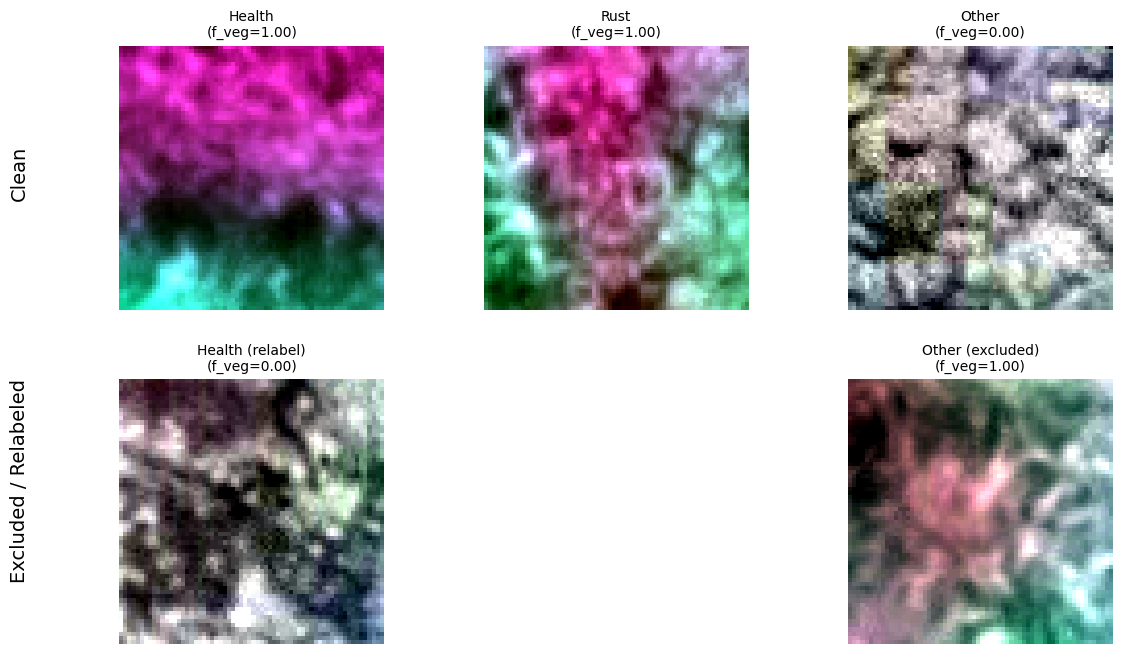


[INFO] Cleaned splits saved under: ./output
[NEXT] 셀 6에서 5-fold 학습/평가 실행 (BalancedBatchSampler 자동 적용).


In [6]:
# ────────────────────────────── 셀 5 (Self-contained + Balanced Batches) ──────────────────────────────
# ---- (안전) CFG에 스위치가 없으면 기본값 세팅 ----
if not hasattr(CFG, "use_balanced_batches"):
    CFG.use_balanced_batches = True   # ★ 기본: 배치-레벨 균형
if not hasattr(CFG, "use_weighted_sampler"):
    CFG.use_weighted_sampler = False  # 필요 시만 사용

# =============== A) NDVI 유틸 & 정리 로직 (셀 3.5 없이 이 셀에 포함) ===============
def _nearest_idx(wl_axis, target_nm):
    return int(np.argmin(np.abs(wl_axis - target_nm)))

def _choose_red_nir_indices(wl_axis):
    red_candidates = getattr(CFG, "ndvi_red_nm_list", [658, 662, 666, 670, 674])
    nir_candidates = getattr(CFG, "ndvi_nir_primary", [774, 778, 782, 786, 790])
    red_idx = _nearest_idx(wl_axis, float(np.mmedian(red_candidates))) if hasattr(np, 'mmedian') else _nearest_idx(wl_axis, float(np.median(red_candidates)))
    nir_idx = _nearest_idx(wl_axis, float(np.mmedian(nir_candidates))) if hasattr(np, 'mmedian') else _nearest_idx(wl_axis, float(np.median(nir_candidates)))
    return red_idx, nir_idx

def _compute_fveg(path, wl_axis, tau=0.30):
    cube = load_hsi(path)  # (H, W, C)
    r_idx, n_idx = _choose_red_nir_indices(wl_axis)

    red = cube[..., r_idx].astype(np.float32)
    nir = cube[..., n_idx].astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-8)
    f_veg = float((ndvi >= tau).mean())
    return f_veg

def _compose_falsecolor(cube, wl_axis, mode="nir_false", p_stretch=True):
    def ch(nm): return cube[..., _nearest_idx(wl_axis, nm)].astype(np.float32)
    if mode == "nir_false":     # R=NIR, G=Red, B=Green
        R, G, B = ch(785), ch(670), ch(550)
    elif mode == "rededge":
        R, G, B = ch(720), ch(680), ch(550)
    else:  # 기본 RGB 유사
        R, G, B = ch(670), ch(550), ch(500)
    stack = np.stack([R,G,B], -1)
    if p_stretch:
        lo, hi = np.percentile(stack, 2), np.percentile(stack, 98)
        stack = np.clip((stack - lo) / (hi - lo + 1e-8), 0, 1)
    else:
        mn = stack.reshape(-1,3).min(axis=0); mx = stack.reshape(-1,3).max(axis=0)
        stack = np.clip((stack - mn) / (mx - mn + 1e-8), 0, 1)
    return stack

def quick_visualize(rows, title, cols=4, max_n=8, mode="nir_false"):
    rows = rows[:max_n]
    if len(rows) == 0:
        print(f"[{title}] no samples."); return
    n = len(rows); r = int(np.ceil(n/cols))
    plt.figure(figsize=(4*cols, 4*r)); plt.suptitle(title, fontsize=14)
    for i, row in enumerate(rows):
        path = row["path"]; ax = plt.subplot(r, cols, i+1)
        try:
            cube = load_hsi(path); rgb = _compose_falsecolor(cube, WAVELENGTHS, mode, p_stretch=True)
            ax.imshow(rgb); ax.axis('off')
            ax.set_title(f"{os.path.basename(path)[:22]}\n{row.get('old_label','?')}→{row.get('new_label','?')}\n"
                         f"f_veg={row.get('f_veg',0):.2f}, ndvi={row.get('ndvi_med',0):.2f}")
        except Exception as e:
            ax.axis('off'); ax.set_title(f"viz fail: {e}")
    plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

def apply_cleanup_df(df, split_name="split",
                     tau=0.30, fveg_min_hr=0.10, fveg_min_other=0.20):
    """
    규칙(단순화):
      - (Health/Rust) & [f_veg < fveg_min_hr]      → demote_to_Other
      - (Other)       & [f_veg >= fveg_min_other] → exclude_from_training
    반환: (정리 적용된 df_out, 로그 DataFrame)
    """
    df = df.reset_index(drop=True).copy()
    out_records, log_records = [], []

    for i, row in df.iterrows():
        label = row["label"]
        path  = row["path"]

        try:
            f_veg = _compute_fveg(path, WAVELENGTHS, tau=tau)
        except Exception as e:
            out_records.append({"label": label, "path": path})
            log_records.append({
                "split": split_name, "idx_in_split": i,
                "old_label": label, "new_label": label,
                "f_veg": np.nan, "tau": tau,
                "flags": "io_error", "action": "keep",
                "path": path, "error": str(e)
            })
            continue

        action, new_label, flags = "keep", label, ""

        if label in ("Health", "Rust"):
            if f_veg < fveg_min_hr:
                action = "demote_to_Other"
                new_label = "Other"
                flags = "health_rust_nonveg_like"
        elif label == "Other":
            if f_veg >= fveg_min_other:
                action = "exclude_from_training"
                new_label = "Other"
                flags = "other_contains_vegetation"

        if action != "exclude_from_training":
            out_records.append({"label": new_label, "path": path})

        log_records.append({
            "split": split_name, "idx_in_split": i,
            "old_label": label, "new_label": new_label,
            "f_veg": f_veg, "tau": tau,
            "flags": flags, "action": action,
            "path": path
        })

    return pd.DataFrame(out_records), pd.DataFrame(log_records)

# =============== B) 학습 유틸/모델 (원형 유지) + BalancedBatchSampler 추가 ===============
def get_param_counts(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

class CUDATimer:
    def __enter__(self):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        self.t0 = time.time(); return self
    def __exit__(self, exc_type, exc, tb):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        self.elapsed = time.time() - self.t0

def evaluate_with_loss(model, loader, device, criterion):
    model.eval()
    all_loss, P, Y, N = 0.0, [], [], 0
    with torch.no_grad():
        for (x_2d, x_1d), y, _idx in loader:
            # 둘 다 GPU로 올림
            x_2d = x_2d.to(device)
            x_1d = x_1d.to(device)
            y    = y.to(device)

            # 2D + 1D 둘 다 넣어서 forward 호출
            logits = model(x_2d, x_1d)
            loss   = criterion(logits, y)

            all_loss += loss.item() * y.size(0)
            N        += y.size(0)
            P.append(torch.softmax(logits, 1).cpu().numpy())
            Y.append(y.cpu().numpy())

    P, Y = np.concatenate(P), np.concatenate(Y)
    pred = P.argmax(1)
    f1   = f1_score(Y, pred, average='macro')
    acc  = accuracy_score(Y, pred)
    return all_loss / max(N, 1), f1, acc, P, Y


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = None if alpha is None else torch.tensor(alpha, dtype=torch.float32)
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction='none')
        pt = torch.softmax(logits, 1)[torch.arange(logits.size(0)), target]
        loss = (1-pt) ** self.gamma * ce
        if self.alpha is not None:
            a = self.alpha.to(logits.device)[target]
            loss = a * loss
        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum' : return loss.sum()
        return loss

class Spectral1D_PixelPreserve(nn.Module):
    def __init__(self, in_bands=7, out_hw=(7,7)):
        super().__init__()
        self.conv1  = nn.Conv1d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm1d(16)
        self.conv2  = nn.Conv1d(16, 32, kernel_size=3, padding=1, bias=False)
        self.bn2    = nn.BatchNorm1d(32)
        self.pool2d = nn.AdaptiveAvgPool2d(out_hw)

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.permute(0,2,3,1).contiguous().view(B*H*W, 1, C)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        gap = x.mean(dim=-1)  # (B*H*W, 32)
        x = gap.view(B, H, W, 32).permute(0,3,1,2).contiguous()
        x = self.pool2d(x)  # (B,32,7,7)
        return x

# class Spectral1D_PixelPreserve(nn.Module):  # GMP만
#     def __init__(self, in_bands=7, out_hw=(7,7)):
#         super().__init__()
#         self.conv1  = nn.Conv1d(1, 16, kernel_size=3, padding=1, bias=False)
#         self.bn1    = nn.BatchNorm1d(16)
#         self.conv2  = nn.Conv1d(16, 32, kernel_size=3, padding=1, bias=False)
#         self.bn2    = nn.BatchNorm1d(32)
#         self.pool2d = nn.AdaptiveAvgPool2d(out_hw)

#     def forward(self, x):
#         B, C, H, W = x.shape
#         x = x.permute(0,2,3,1).contiguous().view(B*H*W, 1, C)
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))

#         # GMP만 사용
#         gmp = x.amax(dim=-1)  # (B*H*W, 32)

#         # GAP 제거 → gmp만 사용
#         x = gmp.view(B, H, W, 32).permute(0,3,1,2).contiguous()

#         # 2D Adaptive Pooling
#         x = self.pool2d(x)  # (B,32,7,7)
#         return x

class SimpleSAM(nn.Module): # GAP만
    def __init__(self, c_pre, out_ch=128, p_drop=0.3):
        super().__init__()
        #  GAP pooling만 사용
        self.gap  = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self.conv = nn.Conv2d(c_pre, out_ch, kernel_size=3, padding=1, bias=False)
        self.act  = nn.ReLU(inplace=True)
        self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        # GAP 성격의 avg pooling만 적용
        y = self.gap(x)
        y = self.drop(self.act(self.conv(y)))
        return y


# class SimpleSAM(nn.Module):
#     def __init__(self, c_pre, out_ch=128, p_drop=0.3):
#         super().__init__()
#         self.avg  = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
#         self.max  = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
#         self.conv = nn.Conv2d(2*c_pre, out_ch, kernel_size=3, padding=1, bias=False)
#         self.act  = nn.ReLU(inplace=True)
#         self.drop = nn.Dropout(p_drop)
#     def forward(self, x):
#         y = torch.cat([self.avg(x), self.max(x)], dim=1)
#         y = self.drop(self.act(self.conv(y)))
#         return y

# class Spectral1D_PixelPreserve(nn.Module):
#     def __init__(self, in_bands=7, out_hw=(7,7)):
#         super().__init__()
#         self.conv1  = nn.Conv1d(1, 16, kernel_size=3, padding=1, bias=False)
#         self.bn1    = nn.BatchNorm1d(16)
#         self.conv2  = nn.Conv1d(16, 32, kernel_size=3, padding=1, bias=False)
#         self.bn2    = nn.BatchNorm1d(32)
#         self.pool2d = nn.AdaptiveAvgPool2d(out_hw)
#     def forward(self, x):
#         B, C, H, W = x.shape
#         x = x.permute(0,2,3,1).contiguous().view(B*H*W, 1, C)
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         gap = x.mean(dim=-1); gmp = x.amax(dim=-1)
#         x = torch.cat([gap, gmp], dim=1).view(B, H, W, 64).permute(0,3,1,2).contiguous()
#         x = self.pool2d(x)  # (B,64,7,7)
#         return x

class HybridResNet_Method1(nn.Module):
    def __init__(self, in_bands_1d=7, n_classes=3, head_pdrop=0.2):
        super().__init__()
        self.spatial_extractor = timm.create_model(
            'resnet18', pretrained=True, features_only=True,
            out_indices=[4], in_chans=3
        )
        self.spectral_extractor = Spectral1D_PixelPreserve()  # (B,64,7,7)

        fuse_in = 512 + 32 #64
        self.fuse = nn.Sequential(
            nn.Conv2d(fuse_in, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout(0.2),
        )
        self.sam  = SimpleSAM(c_pre=256, out_ch=128, p_drop=0.3)
        self.head = nn.Linear(128, n_classes)

    def extract_featmap(self, x2d, x1d):
        f2d = self.spatial_extractor(x2d)[0]   # (B,512,7,7)
        f1d = self.spectral_extractor(x1d)     # (B,64,7,7)
        f = torch.cat([f2d, f1d], dim=1)       # (B,576,7,7)
        f = self.fuse(f)                       # (B,256,7,7)
        f = self.sam(f)                        # (B,128,7,7)
        return f

    def forward(self, x2d, x1d):
        f = self.extract_featmap(x2d, x1d)
        g = F.adaptive_avg_pool2d(f, 1).flatten(1)   # (B,128)
        return self.head(g)

def build_param_groups_C1(model):
    groups = []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        lr = CFG.lr_head; wd = CFG.hsi_wd
        if 'spatial_extractor' in n:
            if   'layer1' in n or 'conv1' in n or 'bn1' in n: lr = CFG.lr_l1l2
            elif 'layer2' in n: lr = CFG.lr_l1l2
            elif 'layer3' in n: lr = CFG.lr_l3
            elif 'layer4' in n: lr = CFG.lr_l4
            else:               lr = CFG.lr_l4
        groups.append({'params': [p], 'lr': lr, 'weight_decay': wd})
    return groups

# ---------- ★ BalancedBatchSampler: 배치 단위 클래스 균형 ----------
class BalancedBatchSampler(Sampler):
    """
    각 배치에 가능한 한 균등하게 class를 배치.
    - oversample 방식(클래스 인덱스를 순환)으로 배치 수를 채움
    - batch_size가 n_classes로 나눠떨어지지 않아도 균형 최대화
    """
    def __init__(self, labels_int: np.ndarray, batch_size: int, n_classes: int, seed: int = 42):
        self.labels = np.array(labels_int, dtype=int)
        self.batch_size = int(batch_size)
        self.n_classes = int(n_classes)
        self.rng = np.random.RandomState(seed)

        self.class_to_indices = {c: np.where(self.labels == c)[0].tolist() for c in range(n_classes)}
        for c in range(n_classes):
            self.rng.shuffle(self.class_to_indices[c])
            # 빈 클래스 방지
            if len(self.class_to_indices[c]) == 0:
                raise ValueError(f"BalancedBatchSampler: class {c} has no samples.")

        # 배치 수: 전체 샘플 수 기준
        self.num_batches = int(np.ceil(len(self.labels) / float(self.batch_size)))

        # per-class 최소 할당 + 나머지
        self.per_class_base = max(1, self.batch_size // self.n_classes)
        self.remainder = self.batch_size - self.per_class_base * self.n_classes

        # 각 클래스의 포인터
        self.ptr = {c: 0 for c in range(n_classes)}

    def __len__(self):
        return self.num_batches

    def _take_from_class(self, c, k):
        idxs = []
        pool = self.class_to_indices[c]
        if len(pool) == 0:
            raise ValueError(f"class {c} empty")
        for _ in range(k):
            idxs.append(pool[self.ptr[c]])
            self.ptr[c] = (self.ptr[c] + 1) % len(pool)  # 순환
        return idxs

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []
            # 기본 균등 할당
            for c in range(self.n_classes):
                batch.extend(self._take_from_class(c, self.per_class_base))
            # 남는 자리 채우기: 클래스 순서를 섞어서 공평하게
            if self.remainder > 0:
                order = list(range(self.n_classes))
                self.rng.shuffle(order)
                for c in order[:self.remainder]:
                    batch.extend(self._take_from_class(c, 1))
            # 배치 내부 순서를 섞음
            self.rng.shuffle(batch)
            yield batch

def make_sampler_or_batchsampler(tr_df, label_map):
    """
    우선순위:
      1) CFG.use_balanced_batches == True -> BalancedBatchSampler (배치-레벨 균형)
      2) CFG.use_weighted_sampler == True -> WeightedRandomSampler (에폭-레벨 균형)
      3) 둘 다 False -> None (일반 shuffle)
    """
    labels_int = tr_df['label'].map(label_map).values
    if getattr(CFG, "use_balanced_batches", False):
        return BalancedBatchSampler(labels_int, batch_size=CFG.hsi_batch_size,
                                    n_classes=len(label_map), seed=CFG.seed), "balanced_batch"
    if getattr(CFG, "use_weighted_sampler", False):
        counts = pd.Series(labels_int).value_counts().sort_index().values.astype(np.float32)
        class_weights = counts.sum() / (counts + 1e-6)
        sample_weights = np.array([class_weights[label_map[c]] for c in tr_df['label']])
        sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights),
                                        num_samples=len(sample_weights), replacement=True)
        return sampler, "weighted"
    return None, "none"

# ====== 폴드 학습 ======
def train_one_fold(fold_idx, tr_df, va_df, bands_2d, bands_1d, n_classes=3):
    mu_1d, std_1d = compute_band_stats(tr_df, bands_1d, max_imgs=None, seed=CFG.seed)
    label_map = {'Health':0,'Other':1,'Rust':2} if n_classes==3 else {'Health':0,'Rust':1}

    train_ds = HSIDataset(tr_df, bands_2d, bands_1d, mu_1d, std_1d, label_map,
                          train=True,  out_hw=(CFG.hsi_img_size, CFG.hsi_img_size))
    val_ds   = HSIDataset(va_df,  bands_2d, bands_1d, mu_1d, std_1d, label_map,
                          train=False, out_hw=(CFG.hsi_img_size, CFG.hsi_img_size))

    sampler_or_bsampler, mode = make_sampler_or_batchsampler(tr_df, label_map)
    if mode == "balanced_batch":
        tr_ld = DataLoader(train_ds, batch_sampler=sampler_or_bsampler,
                           collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)
    else:
        tr_ld = DataLoader(train_ds, batch_size=CFG.hsi_batch_size,
                           shuffle=(sampler_or_bsampler is None),
                           sampler=(sampler_or_bsampler if mode=="weighted" else None),
                           collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)

    va_ld = DataLoader(val_ds,   batch_size=CFG.hsi_batch_size, shuffle=False,
                       collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)

    print(f"[Fold {fold_idx}] Sampler mode: {mode}")

    model = HybridResNet_Method1(in_bands_1d=len(bands_1d), n_classes=n_classes).to(CFG.device)
    opt   = torch.optim.AdamW(build_param_groups_C1(model))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=CFG.reduce_factor, patience=CFG.reduce_patience, verbose=True
    )
    crit = FocalLoss(alpha=getattr(CFG, "focal_alpha", None), gamma=2.0) if getattr(CFG, "use_focal_loss", False) \
           else nn.CrossEntropyLoss(label_smoothing=CFG.hsi_ls)

    if CFG.measure_timing:
        tot, trn = get_param_counts(model)
        print(f"[Fold {fold_idx}] Params: total={tot:,} | trainable={trn:,}")

    hist = {k: [] for k in ["train_loss","train_f1","train_acc","val_loss","val_f1","val_acc"]}
    best_f1, best_state, bad_epochs = -1, None, 0

    for ep in range(1, CFG.hsi_epochs + 1):
        model.train(); run_loss, P_tr, Y_tr, N_tr = 0.0, [], [], 0
        for (x_2d, x_1d), y, _i in tr_ld:
            x_2d, x_1d, y = x_2d.to(CFG.device), x_1d.to(CFG.device), y.to(CFG.device)
            opt.zero_grad(); logits = model(x_2d, x_1d)
            loss = crit(logits, y); loss.backward(); opt.step()
            run_loss += loss.item() * y.size(0); N_tr += y.size(0)
            P_tr.append(torch.softmax(logits.detach(), 1).cpu().numpy())
            Y_tr.append(y.cpu().numpy())

        P_tr, Y_tr = np.concatenate(P_tr), np.concatenate(Y_tr)
        train_loss = run_loss / max(N_tr,1)
        train_f1   = f1_score(Y_tr, P_tr.argmax(1), average='macro')
        train_acc  = accuracy_score(Y_tr, P_tr.argmax(1))

        val_loss, val_f1, val_acc, P_va, Y_va = evaluate_with_loss(model, va_ld, CFG.device, crit)
        sched.step(val_loss)

        print(f"[Fold {fold_idx}][{ep:02d}] "
              f"Train Loss: {train_loss:.4f} | F1: {train_f1:.4f} | Acc: {train_acc:.4f} || "
              f"Val Loss: {val_loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

        hist["train_loss"].append(train_loss); hist["train_f1"].append(train_f1); hist["train_acc"].append(train_acc)
        hist["val_loss"].append(val_loss);     hist["val_f1"].append(val_f1);     hist["val_acc"].append(val_acc)

        if val_f1 > best_f1:
            best_f1, bad_epochs, best_state = val_f1, 0, copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1
            if bad_epochs >= CFG.es_patience:
                print(f"[Fold {fold_idx}] Early Stopping!"); break

    if best_state is not None:
        model.load_state_dict(best_state)
    save_path = os.path.join(CFG.model_dir, f"method1_fold{fold_idx}_bestF1{best_f1:.5f}.pt")
    torch.save(model.state_dict(), save_path)
    print(f"[Fold {fold_idx}] Saved: {save_path}")
    return save_path, mu_1d, std_1d

# =============== C) Holdout split (train/test) ===============
LABELS = ["Health", "Other", "Rust"]
label_map_global = {c:i for i,c in enumerate(LABELS)}

y_all_full = hsi_df['label'].map(label_map_global).values
idx_all = np.arange(len(hsi_df))
TEST_RATIO = 0.20

train_idx, test_idx = train_test_split(
    idx_all, test_size=TEST_RATIO, stratify=y_all_full, random_state=CFG.seed
)
train_full_df = hsi_df.iloc[train_idx].reset_index(drop=True)
test_hold_df  = hsi_df.iloc[test_idx ].reset_index(drop=True)
print(f"[Split] Train(Fit+CV): {len(train_full_df)} | Test(Holdout): {len(test_hold_df)}")

# =============== D) NDVI 정리 적용 (Train/Test 모두) ===============
_before_train, _before_test = len(train_full_df), len(test_hold_df)
train_full_df, log_trainfull = apply_cleanup_df(train_full_df, split_name="train_full")
test_hold_df,  log_testhold  = apply_cleanup_df(test_hold_df,  split_name="test_hold")

print("\n=== After NDVI cleanup (applied to TRAIN and TEST) ===")
print(f"train_full_df: {_before_train} → {len(train_full_df)}  | "
      f"demoted={(log_trainfull.action=='demote_to_Other').sum()}  | "
      f"excluded={(log_trainfull.action=='exclude_from_training').sum()}")
print(f"test_hold_df : {_before_test}  → {len(test_hold_df)}  | "
      f"demoted={(log_testhold.action=='demote_to_Other').sum()}  | "
      f"excluded={(log_testhold.action=='exclude_from_training').sum()}")

def _print_dist(df, name):
    vc = df['label'].value_counts().sort_index()
    print(f"\n[{name}] total={len(df)}"); print(vc)

_print_dist(train_full_df, "TRAIN (after cleanup)")
_print_dist(test_hold_df,  "TEST  (after cleanup)")


# =========================================================
# 0) 로그 합치기 (ndvi_med 없이 f_veg만 기준)
# =========================================================
log_all_once = pd.concat([log_trainfull, log_testhold], ignore_index=True)

# io_error / NaN 제거
log_all_once = log_all_once[log_all_once["f_veg"].notna()].copy()

# =========================================================
# 1) False-color (NIR–Red–Green) + 2–98% stretch (블랙박스 방지)
#    R=NIR, G=Red, B=Green
# =========================================================
def _nearest_idx(wl_axis, target_nm):
    wl_axis = np.asarray(wl_axis)
    return int(np.argmin(np.abs(wl_axis - target_nm)))

def _percentile_stretch_01(img3, p_low=2, p_high=98, eps=1e-8):
    """img3: (H,W,3) float"""
    out = np.zeros_like(img3, dtype=np.float32)
    for ch in range(3):
        x = img3[..., ch].astype(np.float32)
        lo, hi = np.nanpercentile(x, [p_low, p_high])
        if not np.isfinite(lo) or not np.isfinite(hi) or (hi - lo) < eps:
            out[..., ch] = 0.0
        else:
            out[..., ch] = np.clip((x - lo) / (hi - lo), 0.0, 1.0)
    return out

def compose_nir_red_green(cube, wl_axis):
    """
    NIR–Red–Green false-color:
      R = NIR (~782nm), G = Red (~666nm), B = Green (~554nm)
    """
    nir_idx   = _nearest_idx(wl_axis, 782)
    red_idx   = _nearest_idx(wl_axis, 666)
    green_idx = _nearest_idx(wl_axis, 554)

    nir   = cube[..., nir_idx].astype(np.float32)
    red   = cube[..., red_idx].astype(np.float32)
    green = cube[..., green_idx].astype(np.float32)

    rgb = np.stack([nir, red, green], axis=-1)  # (H,W,3)
    rgb = _percentile_stretch_01(rgb, p_low=2, p_high=98)
    return rgb

# =========================================================
# 2) 샘플 선택 유틸 (ndvi_med 제거 버전)
# =========================================================
# =========================================================
# 2) 샘플 선택 유틸 (그대로 사용)
# =========================================================
def _pick_topN(df, cond, sort_col, ascending, K):
    sub = df[cond].copy()
    if sub.empty:
        return []
    return sub.sort_values(sort_col, ascending=ascending).head(K).to_dict(orient="records")

def _pick_one(df, cond, sort_col, ascending):
    items = _pick_topN(df, cond, sort_col=sort_col, ascending=ascending, K=1)
    return items[0] if len(items) > 0 else None

# =========================================================
# 3) 2x3 Figure: Row=Clean vs (Excluded/Relabeled), Col=Health/Rust/Other
# =========================================================
col_names = ["Health", "Rust", "Other"]

# --- Row 1: Clean(keep) ---
clean_item = {}
# Health / Rust: f_veg 높은 순 (진짜 식생 ROI)
clean_item["Health"] = _pick_one(
    log_all_once,
    (log_all_once.action == "keep") & (log_all_once.new_label == "Health"),
    sort_col=["f_veg"],
    ascending=[False],
)
clean_item["Rust"] = _pick_one(
    log_all_once,
    (log_all_once.action == "keep") & (log_all_once.new_label == "Rust"),
    sort_col=["f_veg"],
    ascending=[False],
)
# Other: f_veg 낮은 순 (진짜 배경 ROI)
clean_item["Other"] = _pick_one(
    log_all_once,
    (log_all_once.action == "keep") & (log_all_once.new_label == "Other"),
    sort_col=["f_veg"],
    ascending=[True],
)

# --- Row 2: Excluded or Relabeled ---
flag_item = {}

# Health: Health -> Other relabel (배경에 가까운 것: f_veg 낮은 순)
flag_item["Health"] = _pick_one(
    log_all_once,
    (log_all_once.action == "demote_to_Other") & (log_all_once.old_label == "Health"),
    sort_col=["f_veg"],
    ascending=[True],
)

# Rust: Rust에서 relabel/exclude 케이스가 있으면 우선 표시
# (데이터에 없으면 자동으로 빈칸 처리)
rust_relabel = _pick_one(
    log_all_once,
    (log_all_once.action == "demote_to_Other") & (log_all_once.old_label == "Rust"),
    sort_col=["f_veg"],
    ascending=[True],
)
rust_excl = _pick_one(
    log_all_once,
    (log_all_once.action == "exclude_from_training") & (log_all_once.old_label == "Rust"),
    sort_col=["f_veg"],
    ascending=[False],
)
flag_item["Rust"] = rust_relabel if rust_relabel is not None else rust_excl

# Other: Other인데 vegetation 있어서 exclude (대표적으로 f_veg 높은 순)
flag_item["Other"] = _pick_one(
    log_all_once,
    (log_all_once.action == "exclude_from_training") & (log_all_once.old_label == "Other"),
    sort_col=["f_veg"],
    ascending=[False],
)

# =========================================================
# Plot 2x3
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Row labels (왼쪽에 크게)
fig.text(0.02, 0.72, "Clean", rotation=90, va="center", ha="left", fontsize=14)
fig.text(0.02, 0.28, "Excluded / Relabeled", rotation=90, va="center", ha="left", fontsize=14)

for c, cls in enumerate(col_names):
    # ---- Row 1: Clean ----
    ax = axes[0, c]
    item = clean_item[cls]
    if item is None:
        ax.axis("off")
    else:
        cube = load_hsi(item["path"])
        rgb  = compose_nir_red_green(cube, WAVELENGTHS)
        ax.imshow(rgb)
        ax.axis("off")
        ax.set_title(f"{cls}\n(f_veg={item['f_veg']:.2f})", fontsize=10)

    # ---- Row 2: Excluded/Relabeled ----
    ax = axes[1, c]
    item = flag_item[cls]
    if item is None:
        ax.axis("off")
    else:
        cube = load_hsi(item["path"])
        rgb  = compose_nir_red_green(cube, WAVELENGTHS)
        ax.imshow(rgb)
        ax.axis("off")

        # action 표시를 간단히
        act = item.get("action", "")
        if act == "demote_to_Other":
            tag = "relabel"
        elif act == "exclude_from_training":
            tag = "excluded"
        else:
            tag = act

        ax.set_title(f"{cls} ({tag})\n(f_veg={item['f_veg']:.2f})", fontsize=10)

plt.tight_layout(rect=[0.05, 0.0, 1.0, 1.0])
plt.show()





# =============== F) CSV 저장 (셀 6에서 사용) ===============
os.makedirs(CFG.output_dir, exist_ok=True)
log_trainfull.to_csv(os.path.join(CFG.output_dir, "cleanup_log_train_full.csv"), index=False)
log_testhold.to_csv(os.path.join(CFG.output_dir, "cleanup_log_test_hold.csv"),  index=False)
train_full_df.to_csv(os.path.join(CFG.output_dir, "train_full_df_clean.csv"),   index=False)
test_hold_df.to_csv(os.path.join(CFG.output_dir, "test_hold_df_clean.csv"),     index=False)
print("\n[INFO] Cleaned splits saved under:", CFG.output_dir)
print("[NEXT] 셀 6에서 5-fold 학습/평가 실행 (BalancedBatchSampler 자동 적용).")


In [8]:
# =========================
# Cell 5.5) Profiling utils (Params / FLOPs / Inference)
# =========================

def try_compute_flops_dual(model, x2d_shape, x1d_shape, device):
    model = model.to(device).eval()
    x2d = torch.randn(*x2d_shape, device=device)
    x1d = torch.randn(*x1d_shape, device=device)

    try:
        from fvcore.nn import FlopCountAnalysis
        return float(FlopCountAnalysis(model, (x2d, x1d)).total())
    except Exception:
        try:
            from thop import profile
            macs, _ = profile(model, inputs=(x2d, x1d), verbose=False)
            return float(2 * macs)
        except Exception:
            return None

@torch.no_grad()
def benchmark_inference_ms_per_img_dual(model, loader, device, warmup_batches=5, measure_batches=20):
    model.eval()
    if len(loader) == 0:
        return 0.0, 0.0

    it = iter(loader)
    for _ in range(min(warmup_batches, len(loader))):
        (x2d, x1d), _, _ = next(it)
        x2d, x1d = x2d.to(device), x1d.to(device)
        _ = model(x2d, x1d)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t0 = time.time()
    n = 0
    it = iter(loader)
    for _ in range(min(measure_batches, len(loader))):
        (x2d, x1d), _, _ = next(it)
        x2d, x1d = x2d.to(device), x1d.to(device)
        _ = model(x2d, x1d)
        n += x2d.size(0)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    t = time.time() - t0
    ms_per_img = (t / max(n, 1)) * 1000.0
    img_per_s  = max(n, 1) / max(t, 1e-9)
    return ms_per_img, img_per_s



In [14]:
# Rust demote 존재 여부 확인
print("demote_to_Other & old_label=Rust:",
      len(log_all_once[(log_all_once.action=="demote_to_Other") & (log_all_once.old_label=="Rust")]))

# 액션/라벨 분포도 같이 보기
display(log_all_once.groupby(["action","old_label"]).size().reset_index(name="n").sort_values("n", ascending=False))


demote_to_Other & old_label=Rust: 0


,action,old_label,n
4,keep,Rust,200
2,keep,Health,175
3,keep,Other,125
1,exclude_from_training,Other,75
0,demote_to_Other,Health,25


In [9]:
# ========== 최종!! 0) 정리된 split 로드(메모리 없으면 CSV에서) ========== 
def _load_clean_splits():
    base = getattr(CFG, "output_dir","./output")
    tr_p = os.path.join(base, "train_full_df_clean.csv")
    te_p = os.path.join(base, "test_hold_df_clean.csv")
    tr = train_full_df.copy() if 'train_full_df' in globals() and isinstance(train_full_df, pd.DataFrame) else pd.read_csv(tr_p)
    te = test_hold_df.copy()  if 'test_hold_df'  in globals() and isinstance(test_hold_df,  pd.DataFrame) else pd.read_csv(te_p)
    return tr, te

train_full_df, test_hold_df = _load_clean_splits()
print(f"[LOAD] CLEANED splits → train: {len(train_full_df)}, test: {len(test_hold_df)}")

# ========== 1) 5-fold 만들기 & 학습 ==========
LABELS = ["Health", "Other", "Rust"]
label_map_global = {c:i for i,c in enumerate(LABELS)}

skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
y_train = train_full_df['label'].map(label_map_global).values
fold_indices = list(skf.split(train_full_df.index.values, y_train))

saved_models, fold_stats = [], []
for k,(tr_idx, va_idx) in enumerate(fold_indices):
    tr_df = train_full_df.iloc[tr_idx].copy()
    va_df = train_full_df.iloc[va_idx].copy()
    mpath, mu_1d, std_1d = train_one_fold(k, tr_df, va_df, bands_2d, bands_1d, n_classes=len(LABELS))
    saved_models.append(mpath)
    fold_stats.append((mu_1d, std_1d))

# ========== 2) 홀드아웃(test) 앙상블 평가 ==========
def topk_accuracy(probs, y_true, k=1):
    pred_topk = np.argsort(-probs, axis=1)[:, :k]
    hits = np.any(pred_topk == y_true[:, None], axis=1).astype(np.float32)
    return float(hits.mean())

def wilson_ci(p, n, z=1.96):
    if n == 0: return (0.0, 0.0)
    denom = 1 + z**2/n
    center = (p + z*z/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z*z/(4*n*n)))) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

@torch.no_grad()

def eval_holdout_ensemble_return(test_df):
    def fold_id_from(path: str) -> int:
        m = re.search(r'fold(\d+)', os.path.basename(path))
        return int(m.group(1)) if m else -1

    pairs = []
    for k in range(len(fold_stats)):
        mpaths = [p for p in saved_models if fold_id_from(p) == k]
        assert len(mpaths) == 1, f"fold {k} model file not found: {mpaths}"
        pairs.append((k, mpaths[0], fold_stats[k]))

    n_models = len(pairs)
    probs_accum, idx_ref = None, None
    n_classes = len(LABELS)

    from torch.utils.data import DataLoader
    model_cls = HybridResNet_Method1

    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()

    for k, mpath, (mu_1d, std_1d) in pairs:
        ds = HSIDataset(test_df, bands_2d, bands_1d, mu_1d, std_1d, label_map_global,
                        train=False, out_hw=(CFG.hsi_img_size, CFG.hsi_img_size))
        ld = DataLoader(ds, batch_size=CFG.hsi_batch_size, shuffle=False,
                        collate_fn=hsi_hybrid_collate, num_workers=2, pin_memory=True)

        model = model_cls(in_bands_1d=len(bands_1d), n_classes=n_classes).to(CFG.device)
        state = torch.load(mpath, map_location=CFG.device)
        model.load_state_dict(state, strict=False)
        model.eval()

        fold_probs, fold_idxs = [], []
        for (x_2d, x_1d), _y, idxs in ld:
            x_2d, x_1d = x_2d.to(CFG.device), x_1d.to(CFG.device)
            logits = model(x_2d, x_1d)
            fold_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            fold_idxs.append(idxs.cpu().numpy())

        fold_probs = np.concatenate(fold_probs, axis=0)
        fold_idxs  = np.concatenate(fold_idxs,  axis=0)
        ord_k      = np.argsort(fold_idxs)
        fold_probs = fold_probs[ord_k]
        fold_idxs  = fold_idxs[ord_k]

        if probs_accum is None:
            probs_accum = fold_probs / n_models
            idx_ref     = fold_idxs.copy()
        else:
            assert np.array_equal(idx_ref, fold_idxs), "fold sample order mismatch"
            probs_accum += fold_probs / n_models

    if torch.cuda.is_available(): torch.cuda.synchronize()
    elapsed = time.time() - t0

    y_true = test_df.iloc[idx_ref]['label'].map(label_map_global).values
    y_pred = probs_accum.argmax(1)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    with np.errstate(divide='ignore', invalid='ignore'):
        per_class_acc = np.diag(cm) / cm.sum(axis=1)
        per_class_acc = np.nan_to_num(per_class_acc, nan=0.0)

    oa       = accuracy_score(y_true, y_pred)
    aa       = float(per_class_acc.mean())
    kappa    = cohen_kappa_score(y_true, y_pred, labels=np.arange(n_classes))
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print("\n[Holdout Test] Classification Report (cleaned test)\n",
          classification_report(y_true, y_pred, target_names=LABELS, digits=4))
    print(f"[Holdout Test] Acc: {oa:.4f} | Macro-F1: {macro_f1:.4f} | AA: {aa:.4f} | κ: {kappa:.4f}")
    for i, cname in enumerate(LABELS):
        print(f"  - Acc[{cname}]: {per_class_acc[i]:.4f}")
    print("Confusion Matrix:\n", cm)

    # Top-k
    for k in (1,2):
        acck = topk_accuracy(probs_accum, y_true, k=k)
        lo, hi = wilson_ci(acck, len(y_true))
        print(f"Top-{k} Acc: {acck*100:.2f}%  (95% CI: {lo*100:.2f}%, {hi*100:.2f}%)")

    # 산출물 저장
    os.makedirs(CFG.output_dir, exist_ok=True)
    np.save(os.path.join(CFG.output_dir, "holdout_probs.npy"), probs_accum)
    pd.DataFrame({
        "path": test_df.iloc[idx_ref]["path"].values,
        "true": y_true,
        "pred": y_pred
    }).to_csv(os.path.join(CFG.output_dir, "holdout_predictions.csv"), index=False)

    print(f"[HOLDOUT] Elapsed: {elapsed:.1f}s | {elapsed/len(test_df)*1000.0:.2f} ms/img | {len(test_df)/elapsed:.1f} img/s")
    print("[INFO] Saved holdout predictions/probs under:", CFG.output_dir)
    # -------------------------
    # NEW: Params / FLOPs / Inference (대표 fold0)
    # -------------------------
    if getattr(CFG, "measure_timing", True) and len(saved_models) > 0:
        # fold_stats는 (mu_1d, std_1d)만 저장된 상태이므로 2개만 받는다
        rep_mu, rep_sd = fold_stats[0]
        rep_nbands = len(bands_1d)  # 1D branch 채널 수 = bands_1d 개수

        # 대표 모델: 지금 eval에서 쓰는 것과 동일한 클래스/시그니처로 생성
        rep_model = model_cls(in_bands_1d=rep_nbands, n_classes=n_classes).to(CFG.device)
        rep_state = torch.load(saved_models[0], map_location=CFG.device)
        rep_model.load_state_dict(rep_state, strict=False)  # 위에서 strict=False로 로드했으니 동일하게
        rep_model.eval()

        tot, trn = get_param_counts(rep_model)

        flops = try_compute_flops_dual(
            rep_model,
            x2d_shape=(1, 3, CFG.rgb_input_size, CFG.rgb_input_size),
            x1d_shape=(1, rep_nbands, CFG.hsi_img_size, CFG.hsi_img_size),
            device=CFG.device,
        )

        # timing용 loader도 실제 eval과 동일한 Dataset/Collate 사용
        sub_df = test_df.iloc[:min(256, len(test_df))].reset_index(drop=True)
        tim_ds = HSIDataset(
            sub_df, bands_2d, bands_1d, rep_mu, rep_sd, label_map_global,
            train=False, out_hw=(CFG.hsi_img_size, CFG.hsi_img_size)
        )
        tim_ld = DataLoader(
            tim_ds,
            batch_size=CFG.hsi_batch_size,
            shuffle=False,
            collate_fn=hsi_hybrid_collate,
            num_workers=2,
            pin_memory=True
        )

        ms_img, img_s = benchmark_inference_ms_per_img_dual(
            rep_model, tim_ld, CFG.device, warmup_batches=5, measure_batches=20
        )

        prof_tag = "PROPOSED(RepFold0)"
        print(f"[{prof_tag}] Params: total={tot:,} | trainable={trn:,}")
        print(f"[{prof_tag}] FLOPs: {('{:.3e}'.format(flops) if flops is not None else 'N/A (fvcore/thop not installed)')}")
        print(f"[{prof_tag}] Inference: {ms_img:.2f} ms/img | {img_s:.2f} img/s (approx)")

    return {
        "probs": probs_accum, "y_true": y_true,
        "OA": oa, "AA": aa, "kappa": kappa, "macro_f1": macro_f1,
        "per_class_acc": per_class_acc, "cm": cm
    }
# 실행
stage0_eval = eval_holdout_ensemble_return(test_hold_df)

[LOAD] CLEANED splits → train: 417, test: 108
[Fold 0] Sampler mode: balanced_batch


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

[Fold 0] Params: total=12,727,379 | trainable=12,727,379


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Fold 0][01] Train Loss: 0.7176 | F1: 0.6734 | Acc: 0.6786 || Val Loss: 0.6567 | F1: 0.5122 | Acc: 0.5833
[Fold 0][02] Train Loss: 0.5296 | F1: 0.7492 | Acc: 0.7530 || Val Loss: 0.5831 | F1: 0.6671 | Acc: 0.6429
[Fold 0][03] Train Loss: 0.5056 | F1: 0.7557 | Acc: 0.7589 || Val Loss: 0.5602 | F1: 0.6891 | Acc: 0.6667
[Fold 0][04] Train Loss: 0.4968 | F1: 0.7393 | Acc: 0.7411 || Val Loss: 0.5466 | F1: 0.7055 | Acc: 0.6905
[Fold 0][05] Train Loss: 0.4758 | F1: 0.7689 | Acc: 0.7708 || Val Loss: 0.5593 | F1: 0.7559 | Acc: 0.7381
[Fold 0][06] Train Loss: 0.4293 | F1: 0.8020 | Acc: 0.8036 || Val Loss: 0.5749 | F1: 0.7227 | Acc: 0.7024
[Fold 0][07] Train Loss: 0.4766 | F1: 0.7807 | Acc: 0.7798 || Val Loss: 0.5957 | F1: 0.6756 | Acc: 0.6548
[Fold 0][08] Train Loss: 0.4367 | F1: 0.8140 | Acc: 0.8155 || Val Loss: 0.5526 | F1: 0.7438 | Acc: 0.7262
[Fold 0][09] Train Loss: 0.4788 | F1: 0.7708 | Acc: 0.7708 || Val Loss: 0.5350 | F1: 0.7504 | Acc: 0.7381
[Fold 0][10] Train Loss: 0.4368 | F1: 0.7958 |

...

[Fold 2][01] Train Loss: 0.7174 | F1: 0.6451 | Acc: 0.6369 || Val Loss: 0.7014 | F1: 0.6813 | Acc: 0.6747
[Fold 2][02] Train Loss: 0.5344 | F1: 0.7254 | Acc: 0.7321 || Val Loss: 0.6129 | F1: 0.6865 | Acc: 0.6747
[Fold 2][03] Train Loss: 0.4963 | F1: 0.7326 | Acc: 0.7351 || Val Loss: 0.6343 | F1: 0.6916 | Acc: 0.6867
[Fold 2][04] Train Loss: 0.4833 | F1: 0.7600 | Acc: 0.7619 || Val Loss: 0.6043 | F1: 0.6870 | Acc: 0.6747
[Fold 2][05] Train Loss: 0.4677 | F1: 0.7652 | Acc: 0.7679 || Val Loss: 0.6663 | F1: 0.6532 | Acc: 0.6386
[Fold 2][06] Train Loss: 0.4540 | F1: 0.7997 | Acc: 0.8006 || Val Loss: 0.5895 | F1: 0.7036 | Acc: 0.6867
[Fold 2][07] Train Loss: 0.4544 | F1: 0.7988 | Acc: 0.7976 || Val Loss: 0.6093 | F1: 0.6403 | Acc: 0.6265
[Fold 2][08] Train Loss: 0.4207 | F1: 0.8171 | Acc: 0.8185 || Val Loss: 0.5656 | F1: 0.6911 | Acc: 0.6988
[Fold 2][09] Train Loss: 0.4217 | F1: 0.7859 | Acc: 0.7857 || Val Loss: 0.5591 | F1: 0.7233 | Acc: 0.7349
[Fold 2][10] Train Loss: 0.4355 | F1: 0.8104 |

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Fold 3][01] Train Loss: 0.7367 | F1: 0.6226 | Acc: 0.6161 || Val Loss: 0.6499 | F1: 0.6368 | Acc: 0.6265
[Fold 3][02] Train Loss: 0.5148 | F1: 0.7185 | Acc: 0.7232 || Val Loss: 0.6083 | F1: 0.6122 | Acc: 0.6145
[Fold 3][03] Train Loss: 0.5075 | F1: 0.7394 | Acc: 0.7411 || Val Loss: 0.5608 | F1: 0.7371 | Acc: 0.7229
[Fold 3][04] Train Loss: 0.4852 | F1: 0.7602 | Acc: 0.7619 || Val Loss: 0.5603 | F1: 0.7279 | Acc: 0.7229
[Fold 3][05] Train Loss: 0.4578 | F1: 0.7839 | Acc: 0.7857 || Val Loss: 0.5909 | F1: 0.6714 | Acc: 0.6506
[Fold 3][06] Train Loss: 0.4537 | F1: 0.7874 | Acc: 0.7887 || Val Loss: 0.5677 | F1: 0.7178 | Acc: 0.6988
[Fold 3][07] Train Loss: 0.4337 | F1: 0.8021 | Acc: 0.8006 || Val Loss: 0.5803 | F1: 0.7598 | Acc: 0.7470
[Fold 3][08] Train Loss: 0.4308 | F1: 0.8200 | Acc: 0.8214 || Val Loss: 0.5696 | F1: 0.7086 | Acc: 0.6988
[Fold 3][09] Train Loss: 0.4573 | F1: 0.8110 | Acc: 0.8125 || Val Loss: 0.5822 | F1: 0.6903 | Acc: 0.6867
[Fold 3][10] Train Loss: 0.3746 | F1: 0.8622 |

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Fold 4][01] Train Loss: 0.7148 | F1: 0.6485 | Acc: 0.6548 || Val Loss: 0.6486 | F1: 0.5491 | Acc: 0.6024
[Fold 4][02] Train Loss: 0.5193 | F1: 0.7383 | Acc: 0.7411 || Val Loss: 0.6041 | F1: 0.6848 | Acc: 0.6747
[Fold 4][03] Train Loss: 0.5194 | F1: 0.7378 | Acc: 0.7411 || Val Loss: 0.5571 | F1: 0.7109 | Acc: 0.6988
[Fold 4][04] Train Loss: 0.4895 | F1: 0.7394 | Acc: 0.7440 || Val Loss: 0.5094 | F1: 0.7710 | Acc: 0.7590
[Fold 4][05] Train Loss: 0.4860 | F1: 0.7458 | Acc: 0.7500 || Val Loss: 0.4802 | F1: 0.7938 | Acc: 0.7831
[Fold 4][06] Train Loss: 0.4887 | F1: 0.7643 | Acc: 0.7649 || Val Loss: 0.5272 | F1: 0.7137 | Acc: 0.6988
[Fold 4][07] Train Loss: 0.4372 | F1: 0.8250 | Acc: 0.8244 || Val Loss: 0.5067 | F1: 0.7596 | Acc: 0.7470
[Fold 4][08] Train Loss: 0.4575 | F1: 0.7690 | Acc: 0.7708 || Val Loss: 0.5539 | F1: 0.7497 | Acc: 0.7470
[Fold 4][09] Train Loss: 0.4491 | F1: 0.7917 | Acc: 0.7917 || Val Loss: 0.4903 | F1: 0.7110 | Acc: 0.6988
[Fold 4][10] Train Loss: 0.4305 | F1: 0.8258 |